# Análisis explicativo
El objetivo de este notebook es hacer un análisis explicativo sobre el mejor modelo obtenido para entender cuáles son las features más y menos importante y qué efecto tienen sobre el precio.

Para ello, se va a utilizar el modelo XGBoost con los mejores parámetros encontrados (ya que es más interpretable que el modelo híbrido.

In [1]:
%load_ext autoreload
%autoreload 2

import os, sys
sys.path.append(os.path.abspath(".."))

import shap
import numpy as np
from tqdm import tqdm
import seaborn as sns
sns.set_theme(style="whitegrid")

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn import set_config
set_config(transform_output="pandas")

from src.plots import plot_shap_feature_importance, \
    plot_shap_impact_heatmap, plot_shap_amenities_impact, plot_shap_dependence_grid, \
    plot_shap_discrete_impact_bars
from src.models.xgboost_models import get_xgboost_full
from src.constants import DevSetType, TARGET, COLS
from src.utils import get_dev_set

shap.initjs()

In [2]:
df = get_dev_set(DevSetType.NORMAL)
X = df.drop(columns=[TARGET])
y = df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Entrenamos modelo (y verificamos métricas por las dudas)

In [3]:
model = get_xgboost_full()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

In [4]:
print(f"RMSE: ${rmse:,.0f}")
print(f"MAE: ${mae:,.0f}")

RMSE: $6,630
MAE: $2,350


Preparamos dataset & regresor a explicar

In [5]:
preprocessor = model.regressor_.named_steps["features"]
X_test_sample, _, y_test_sample, _ = train_test_split(X_test, y_test, train_size=10000, random_state=42, stratify=X_test[COLS.PROVINCIA])
X_test_transformed = preprocessor.transform(X_test_sample)

In [6]:
X_test_transformed["ITE_ADD_STATE_NAME_Capital Federal"].mean()

np.float64(0.5687)

In [7]:
xgb_regressor = model.regressor_.named_steps["model"]

In [8]:
explainer = shap.TreeExplainer(xgb_regressor)

In [11]:
n_samples = len(X_test_transformed)
batch_size=100
shap_values_list = []

for i in tqdm(range(0, n_samples, batch_size), desc="SHAP Progress"):
    batch = X_test_transformed[i:i+batch_size]
    shap_batch = explainer.shap_values(batch, check_additivity=False)
    shap_values_list.append(shap_batch)

SHAP Progress: 100%|██████████| 100/100 [14:39<00:00,  8.79s/it]


In [12]:
shap_values = np.vstack(shap_values_list)
feature_names = X_test_transformed.columns.tolist()
shap_values.shape

(10000, 42)

In [13]:
# Guardamos los resultados para no tener que correrlo de nuevo
np.save("../results/analisis_explicativo/shap_values_sin_outliers.npy", shap_values)

In [9]:
shap_values = np.load("../results/analisis_explicativo/shap_values_sin_outliers.npy")
feature_names = np.load("../results/analisis_explicativo/feature_names.npy")

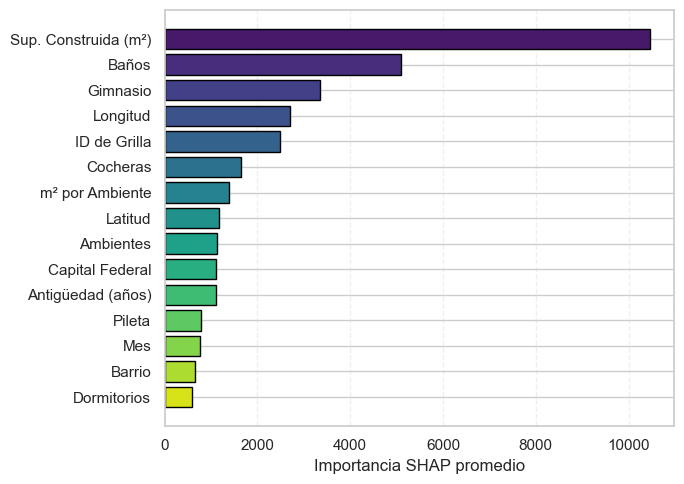

In [11]:
plot_shap_feature_importance(shap_values, feature_names, top_n=15, filename="analisis-explicativo/01-feature-importance")

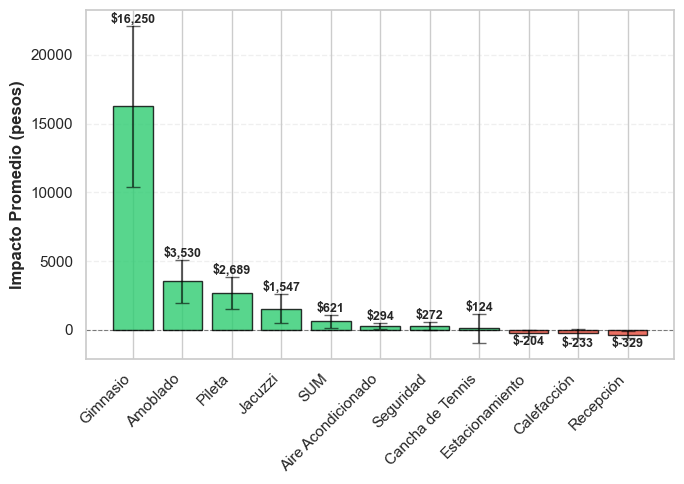

,Feature,Impacto,Std,N_con,N_sin,Feature_legible
1,Gimnasio,16250.161133,5849.996094,1096,7710,Gimnasio
0,Amoblado,3529.751221,1556.301270,736,8152,Amoblado
9,Pileta,2688.915283,1134.900024,1664,7323,Pileta
7,Jacuzzi,1547.157471,1069.063721,428,8285,Jacuzzi
3,SUM,621.167114,501.692688,1373,6516,SUM
4,AireAC,293.865509,248.505081,2886,6122,Aire Acondicionado
8,Seguridad,272.327637,299.002319,1084,7712,Seguridad
10,CanchaTennis,124.340363,1047.986816,50,7464,Cancha de Tennis
6,Estacionamiento,-204.110336,211.629593,104,7429,Estacionamiento
2,Calefaccion,-233.451126,333.120026,1630,7308,Calefacción


In [16]:
amenities = [COLS.AMOBLADO, COLS.GIMNASIO, COLS.CALEFACCION, COLS.SUM, COLS.AIRE, COLS.RECEPCION, COLS.ESTACIONAMIENTO, COLS.JACUZZI, COLS.SEGURIDAD, COLS.PILETA, COLS.TENNIS]
plot_shap_amenities_impact(shap_values, X_test_sample, feature_names, features_to_analyze=amenities, use_median=False, filter_outliers=True, filename="analisis-explicativo/02-amenities-impact")

/Users/gonza/Documents/Gonza/UdeSA/05-machine-learning/alquileres/src/plots.py:60: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ax.set_xlabel(col)


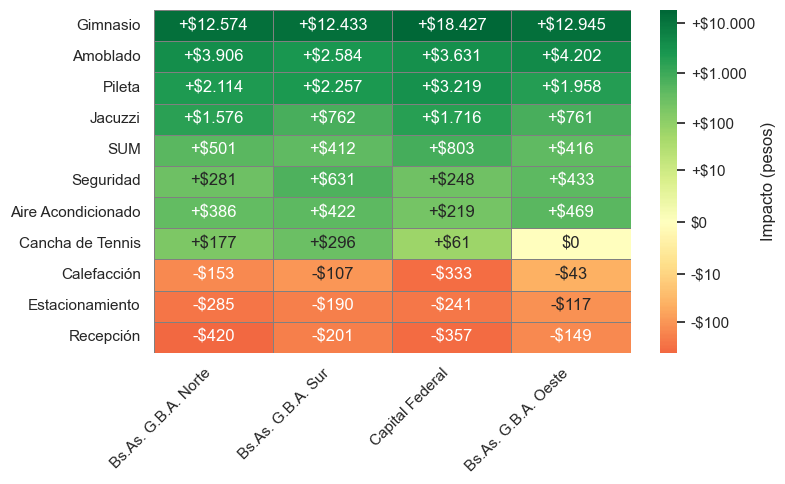

,Gimnasio,Amoblado,Pileta,Jacuzzi,SUM,Seguridad,Aire Acondicionado,Cancha de Tennis,Calefacción,Estacionamiento,Recepción
Bs.As. G.B.A. Norte,12574.052734,3905.843262,2114.356934,1576.409790,501.008850,280.856262,385.634460,176.817780,-153.023468,-284.662109,-420.391785
Bs.As. G.B.A. Sur,12432.641602,2584.395996,2257.194824,761.581726,411.869476,630.969482,421.598663,296.086151,-106.582069,-190.487717,-200.585968
Capital Federal,18427.390625,3630.799316,3218.957764,1716.107666,802.870361,248.087952,219.186066,60.734436,-333.326843,-241.151749,-356.606384
Bs.As. G.B.A. Oeste,12945.320312,4202.058594,1957.642334,760.832825,416.406128,433.168701,468.671204,0.000000,-42.781792,-117.046173,-148.644928


In [18]:
plot_shap_impact_heatmap(shap_values, X_test_sample, feature_names, zone_column=COLS.PROVINCIA, features_to_analyze=amenities, filename="analisis-explicativo/03-amenities-impact-per-state")

/Users/gonza/Documents/Gonza/UdeSA/05-machine-learning/alquileres/src/plots.py:60: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ax.set_xlabel(col)


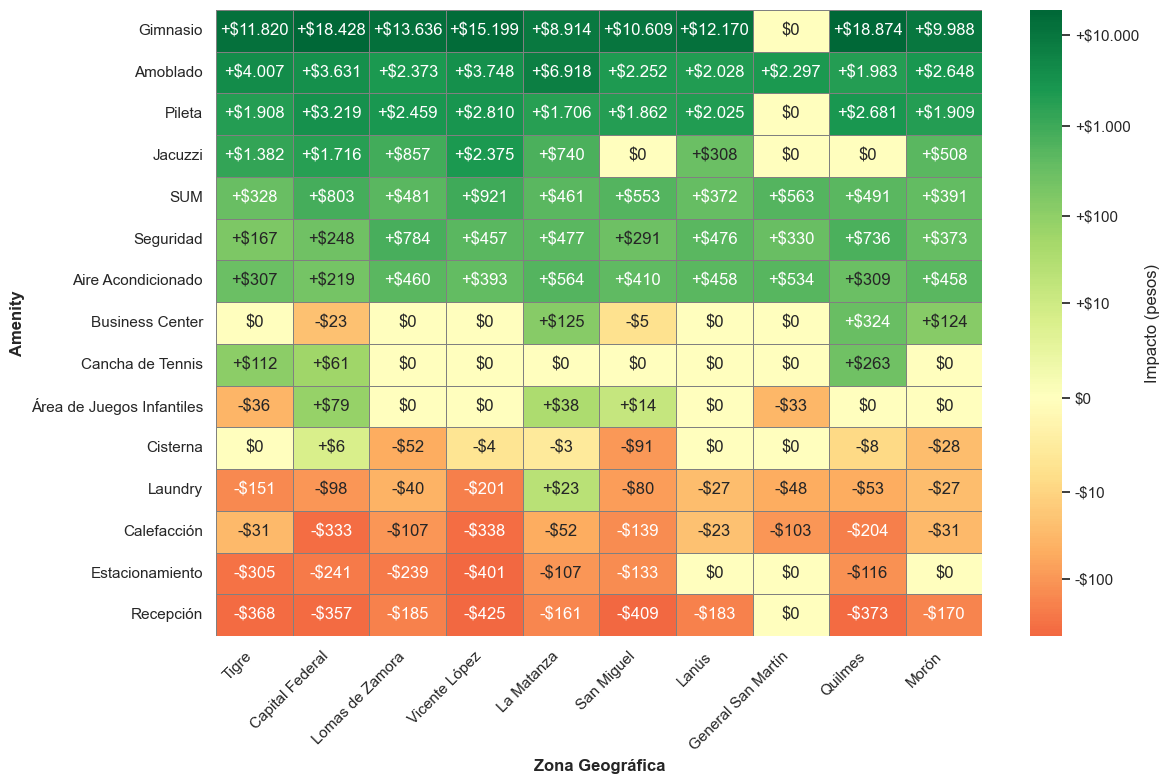

,Gimnasio,Amoblado,Pileta,Jacuzzi,SUM,Seguridad,Aire Acondicionado,Business Center,Cancha de Tennis,Área de Juegos Infantiles,Cisterna,Laundry,Calefacción,Estacionamiento,Recepción
Tigre,11820.296875,4007.329346,1908.034546,1381.962646,327.603333,167.309906,307.021576,0.000000,111.793007,-36.314651,0.000000,-150.779434,-30.728937,-304.613831,-368.164215
Capital Federal,18428.453125,3630.923584,3219.231689,1716.169067,802.961670,248.079987,219.113129,-22.708353,60.733624,79.167145,6.313661,-98.167473,-333.395020,-241.154861,-356.612183
Lomas de Zamora,13635.978516,2372.946289,2459.004395,857.274841,481.211761,784.418091,460.147827,0.000000,0.000000,0.000000,-51.722855,-39.793545,-107.454987,-238.608459,-184.610413
Vicente López,15199.128906,3748.361328,2809.719727,2375.197021,921.011719,456.505493,393.038879,0.000000,0.000000,0.000000,-4.131739,-201.362305,-338.342041,-400.796783,-425.117981
La Matanza,8913.931641,6917.776855,1705.873169,739.693176,460.685303,477.229034,564.440430,124.790573,0.000000,38.208694,-2.576097,23.103281,-51.866753,-107.353104,-161.183578
San Miguel,10608.620117,2252.065186,1862.462158,0.000000,553.264099,291.468048,410.324402,-4.975687,0.000000,14.447653,-91.066444,-80.054634,-139.435013,-133.418976,-409.461121
Lanús,12170.341797,2028.050049,2024.773438,308.265594,371.927582,475.959015,457.504364,0.000000,0.000000,0.000000,0.000000,-26.898371,-23.424511,0.000000,-183.369293
General San Martín,0.000000,2297.243652,0.000000,0.000000,562.715210,329.906891,533.720459,0.000000,0.000000,-33.315178,0.000000,-48.307953,-102.547340,0.000000,0.000000
Quilmes,18874.205078,1983.365723,2681.477783,0.000000,491.333374,735.674805,308.702972,323.913513,262.995697,0.000000,-7.614734,-53.229713,-204.419373,-115.997025,-373.172913
Morón,9987.673828,2647.906738,1908.982910,507.863953,391.479645,373.373840,457.827606,124.499733,0.000000,0.000000,-27.640530,-26.839617,-30.712849,0.000000,-169.771500


In [96]:
plot_shap_impact_heatmap(shap_values, X_test_sample, feature_names, zone_column=COLS.CIUDAD, features_to_analyze=amenities, filename="analisis-explicativo/04-amenities-impact-per-city", top_n=10)

/Users/gonza/Documents/Gonza/UdeSA/05-machine-learning/alquileres/src/plots.py:60: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ax.set_xlabel(col)


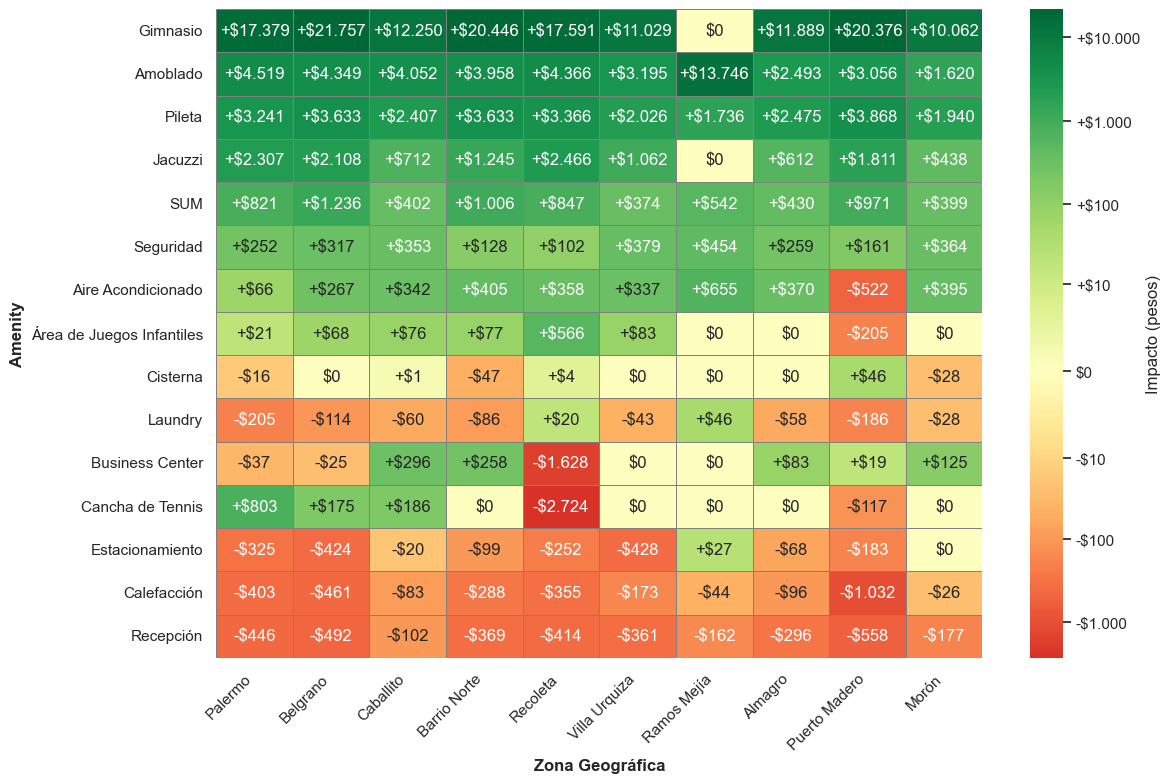

,Gimnasio,Amoblado,Pileta,Jacuzzi,SUM,Seguridad,Aire Acondicionado,Área de Juegos Infantiles,Cisterna,Laundry,Business Center,Cancha de Tennis,Estacionamiento,Calefacción,Recepción
Palermo,17378.724609,4519.196289,3241.172607,2307.400879,820.518860,251.800903,65.615463,20.985159,-16.388567,-204.755478,-36.956047,803.349792,-324.771820,-403.027985,-445.969238
Belgrano,21756.537109,4348.683105,3633.287109,2107.709473,1235.740723,317.128754,266.614807,67.872086,0.000000,-114.155510,-24.668482,175.273453,-423.520874,-460.533142,-491.708710
Caballito,12250.134766,4052.239990,2406.947754,712.072571,401.826355,353.287903,342.323059,75.892410,0.679552,-59.827740,296.007080,185.672424,-19.518799,-83.221024,-102.173050
Barrio Norte,20446.488281,3958.107910,3632.888672,1245.322510,1005.570312,128.392563,404.963440,77.447189,-47.071991,-85.547272,258.276367,0.000000,-98.749008,-288.087524,-369.284607
Recoleta,17591.054688,4366.117676,3366.487061,2466.157959,847.358826,102.229652,358.281372,565.508545,4.001396,20.257851,-1627.605469,-2723.871826,-251.524704,-354.932220,-413.581451
Villa Urquiza,11028.563477,3194.665039,2025.652466,1061.810669,374.452087,378.836243,337.211639,82.799004,0.000000,-43.318558,0.000000,0.000000,-427.714691,-173.230957,-361.385223
Ramos Mejía,0.000000,13746.060547,1735.796631,0.000000,541.689819,453.915924,655.435974,0.000000,0.000000,45.510612,0.000000,0.000000,27.382542,-44.493469,-161.562897
Almagro,11888.636719,2493.363770,2474.799805,611.644592,430.246704,259.239471,369.557617,0.000000,0.000000,-57.912899,82.661148,0.000000,-67.753235,-95.788727,-296.356903
Puerto Madero,20375.998047,3056.040039,3868.018555,1810.729004,971.260864,161.170425,-522.033508,-204.876480,46.468395,-185.764633,19.359941,-117.056503,-183.447662,-1031.897949,-558.199036
Morón,10061.667969,1619.732422,1940.335083,438.007202,398.901123,364.307953,394.973389,0.000000,-27.648729,-27.550739,124.537209,0.000000,0.000000,-26.223429,-177.415283


In [98]:
plot_shap_impact_heatmap(shap_values, X_test_sample, feature_names, zone_column=COLS.BARRIO, features_to_analyze=amenities, filename="analisis-explicativo/05-amenities-impact-per-neighborhood", top_n=10)

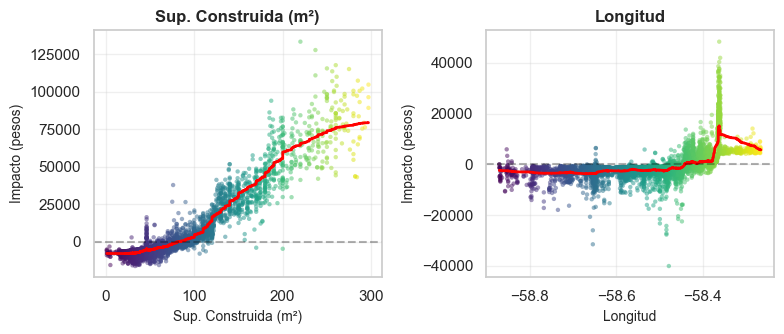

In [19]:
plot_shap_dependence_grid(shap_values, X_test_transformed, feature_names, features_to_plot=[COLS.SUP_CONSTR, COLS.LONGITUD], filter_outliers=True, filename="analisis-explicativo/06-continuous-feats-impact")

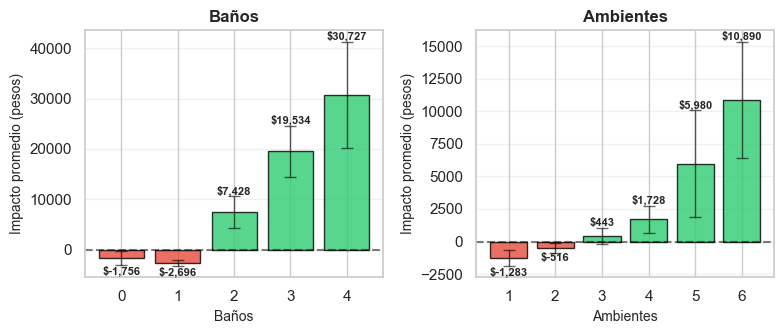

{'Banos':    Valor       Impacto           Std     N
 0    0.0  -1755.594238   1384.835083   187
 1    1.0  -2695.709229    577.834351  7403
 2    2.0   7427.932617   3182.522949  1637
 3    3.0  19533.517578   5091.760254   518
 4    4.0  30726.962891  10594.889648   172,
 'Ambientes':    Valor       Impacto          Std     N
 0    1.0  -1282.962524   600.789062  1966
 1    2.0   -516.125122   381.698578  4184
 2    3.0    442.788422   597.943420  2414
 3    4.0   1727.808594  1035.318115   941
 4    5.0   5980.139648  4118.957031   273
 5    6.0  10890.125977  4476.274414   118}

In [20]:
plot_shap_discrete_impact_bars(shap_values, X_test_sample, feature_names, features_to_plot=[COLS.BANOS, COLS.AMBIENTES], filter_outliers=True, filename="analisis-explicativo/07-discrete-feats-impact")